В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [83]:
import pandas as pd

train = pd.read_csv('/content/sample_data/train.csv')
test = pd.read_csv('/content/sample_data/test.csv')
sample = pd.read_csv('/content/sample_data/sample_submission.csv')


In [3]:
train.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


In [5]:
#Розбиваємо фрейм на тренувальний та валідаційний
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train,
    test_size=0.2,
    random_state=42,
    stratify=train["Exited"] #Однакові пропорції класів Exited у всіх піднаборах
)


In [6]:
print('train_df.shape:', train_df.shape)
print('val_df.shape:', val_df.shape)

train_df.shape: (12000, 14)
val_df.shape: (3000, 14)


2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [7]:
#Призначаємо вхідні стовпці
input_cols = list(train.columns)[1:-1]

In [8]:
# усі колонки, крім останньої (Exited)
input_cols = list(train.columns)[:-1]

# видаляємо нерелевантні колонки
input_cols.remove('Surname')
input_cols.remove('id')
input_cols.remove('CustomerId')

print(input_cols)


['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


Пояснення щодо видалення **Surname** і (**ID** та **CustomerID** аналогічно)

Прізвище не несе корисної інформації для моделі.

Воно не має логічного зв’язку з поведінкою клієнта.

Воно створює зайвий шум.

In [9]:
#Призначаємо  цільовий стовпець
target_col='Exited'

In [10]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

In [11]:
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

In [12]:
display(train_inputs.head())
display(val_inputs.head())


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
7180,682.0,France,Male,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24
10393,684.0,France,Female,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31
80,705.0,Germany,Male,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01
3365,669.0,Spain,Male,58.0,0.0,0.00,2.0,0.0,1.0,51565.98
12236,707.0,France,Male,21.0,3.0,0.00,2.0,1.0,1.0,148564.76


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
6490,714.0,Germany,Male,46.0,1.0,115764.32,4.0,1.0,1.0,72945.32
3646,593.0,France,Male,41.0,5.0,0.00,2.0,1.0,1.0,38196.24
5306,731.0,France,Female,38.0,2.0,0.00,2.0,0.0,1.0,116971.05
652,673.0,France,Female,43.0,4.0,155739.76,1.0,0.0,1.0,111622.76
2627,678.0,Spain,Female,30.0,4.0,0.00,2.0,1.0,0.0,143681.85


3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [13]:
import numpy as np

In [14]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

In [15]:
numeric_cols, categorical_cols

(['CreditScore',
  'Age',
  'Tenure',
  'Balance',
  'NumOfProducts',
  'HasCrCard',
  'IsActiveMember',
  'EstimatedSalary'],
 ['Geography', 'Gender'])

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

**Кодування категоріальних колонок**

In [16]:
#Кодуємо колнки Geography and Gender. Це може мати вплив, далі з'ясуємо.
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

cat_cols = ['Geography', 'Gender']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(train_inputs[cat_cols])

train_encoded = encoder.transform(train_inputs[cat_cols])
val_encoded = encoder.transform(val_inputs[cat_cols])

encoded_cols = encoder.get_feature_names_out(cat_cols)

train_encoded_df = pd.DataFrame(train_encoded, columns=encoded_cols, index=train_inputs.index)
val_encoded_df = pd.DataFrame(val_encoded, columns=encoded_cols, index=val_inputs.index)

train_inputs = train_inputs.drop(columns=cat_cols)
val_inputs = val_inputs.drop(columns=cat_cols)

train_inputs = pd.concat([train_inputs, train_encoded_df], axis=1)
val_inputs = pd.concat([val_inputs, val_encoded_df], axis=1)

display(train_inputs.head())
display(val_inputs.head())


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
7180,682.0,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24,1.0,0.0,0.0,0.0,1.0
10393,684.0,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31,1.0,0.0,0.0,1.0,0.0
80,705.0,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01,0.0,1.0,0.0,0.0,1.0
3365,669.0,58.0,0.0,0.00,2.0,0.0,1.0,51565.98,0.0,0.0,1.0,0.0,1.0
12236,707.0,21.0,3.0,0.00,2.0,1.0,1.0,148564.76,1.0,0.0,0.0,0.0,1.0


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
6490,714.0,46.0,1.0,115764.32,4.0,1.0,1.0,72945.32,0.0,1.0,0.0,0.0,1.0
3646,593.0,41.0,5.0,0.00,2.0,1.0,1.0,38196.24,1.0,0.0,0.0,0.0,1.0
5306,731.0,38.0,2.0,0.00,2.0,0.0,1.0,116971.05,1.0,0.0,0.0,1.0,0.0
652,673.0,43.0,4.0,155739.76,1.0,0.0,1.0,111622.76,1.0,0.0,0.0,1.0,0.0
2627,678.0,30.0,4.0,0.00,2.0,1.0,0.0,143681.85,0.0,0.0,1.0,1.0,0.0


**Масштабування**
Має сенс, оскільки в  датасеті числові ознаки мають дуже різні масштаби

Age 18–92

CreditScore  350–850

Balance  0–250000
інші

In [17]:
num_cols = train_inputs.select_dtypes(include=['float64', 'int64']).columns
print(num_cols)


Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Geography_France',
       'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male'],
      dtype='object')


In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(train_inputs[num_cols])



MinMaxScaler()

In [19]:
train_scaled = scaler.transform(train_inputs[num_cols])
val_scaled = scaler.transform(val_inputs[num_cols])


In [20]:
train_scaled_df = pd.DataFrame(train_scaled, columns=num_cols, index=train_inputs.index)
val_scaled_df = pd.DataFrame(val_scaled, columns=num_cols, index=val_inputs.index)



In [21]:
train_inputs[num_cols] = train_scaled_df
val_inputs[num_cols] = val_scaled_df



In [22]:
display(train_inputs.head())
display(val_inputs.head())


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
7180,0.599045,0.214286,0.1,0.626382,0.000000,1.0,1.0,0.719772,1.0,0.0,0.0,0.0,1.0
10393,0.603819,0.375000,0.2,0.848836,0.000000,1.0,0.0,0.727603,1.0,0.0,0.0,1.0,0.0
80,0.653938,0.303571,0.6,0.554522,0.333333,1.0,0.0,0.872180,0.0,1.0,0.0,0.0,1.0
3365,0.568019,0.714286,0.0,0.000000,0.333333,0.0,1.0,0.257797,0.0,0.0,1.0,0.0,1.0
12236,0.658711,0.053571,0.3,0.000000,0.333333,1.0,1.0,0.742837,1.0,0.0,0.0,0.0,1.0


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
6490,0.675418,0.500000,0.1,0.551870,1.000000,1.0,1.0,0.364704,0.0,1.0,0.0,0.0,1.0
3646,0.386635,0.410714,0.5,0.000000,0.333333,1.0,1.0,0.190942,1.0,0.0,0.0,0.0,1.0
5306,0.715990,0.357143,0.2,0.000000,0.333333,0.0,1.0,0.584853,1.0,0.0,0.0,1.0,0.0
652,0.577566,0.446429,0.4,0.742441,0.000000,0.0,1.0,0.558109,1.0,0.0,0.0,1.0,0.0
2627,0.589499,0.214286,0.4,0.000000,0.333333,1.0,0.0,0.718420,0.0,0.0,1.0,1.0,0.0


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [23]:
!pip install pyarrow --quiet


In [24]:
train_inputs.to_parquet('train_inputs.parquet')
val_inputs.to_parquet('val_inputs.parquet')

pd.DataFrame(train_targets).to_parquet('train_targets.parquet')
pd.DataFrame(val_targets).to_parquet('val_targets.parquet')


In [25]:
import os
os.listdir('/content')


['.config',
 'train_inputs.parquet',
 'val_inputs.parquet',
 'val_targets.parquet',
 'sample_data',
 'train_targets.parquet']

6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [26]:
X_train = train_inputs.copy()
X_val = val_inputs.copy()

y_train = train_targets.copy()
y_val = val_targets.copy()


In [27]:
from sklearn.linear_model import LogisticRegression


In [28]:
model = LogisticRegression(solver='liblinear')


In [29]:
model.fit(X_train, y_train)


LogisticRegression(solver='liblinear')

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

In [30]:
# Прогнози ймовірностей
train_proba = model.predict_proba(X_train)[:, 1]
val_proba = model.predict_proba(X_val)[:, 1]

# Прогнози класів при порозі 0.5
train_pred = (train_proba >= 0.5).astype(int)
val_pred = (val_proba >= 0.5).astype(int)


In [31]:
train_proba

array([0.01464177, 0.27092741, 0.12759346, ..., 0.0072396 , 0.16843937,
       0.05048414])

In [32]:
train_pred

array([0, 0, 0, ..., 0, 0, 0])

In [33]:
from sklearn.metrics import confusion_matrix

print("Train Confusion Matrix:")
print(confusion_matrix(y_train, train_pred))

print("\nValidation Confusion Matrix:")
print(confusion_matrix(y_val, val_pred))


Train Confusion Matrix:
[[9177  381]
 [1128 1314]]

Validation Confusion Matrix:
[[2271  119]
 [ 266  344]]


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [53]:
def predict_and_plot(inputs, targets, name=''):
    preds = model.predict(inputs)

    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))

    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name));

    return preds

Accuracy: 87.42%


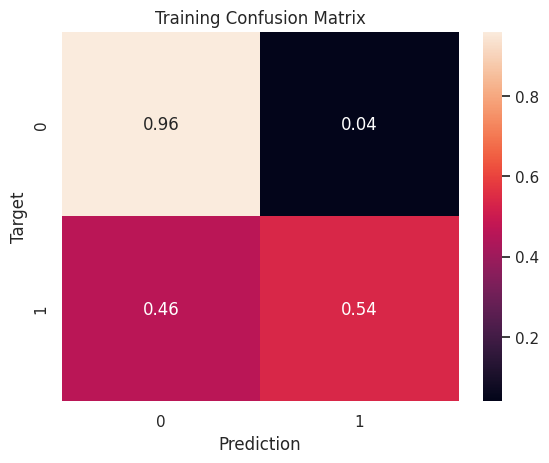

In [54]:
train_preds = predict_and_plot(X_train, y_train, 'Training')

Accuracy: 87.17%


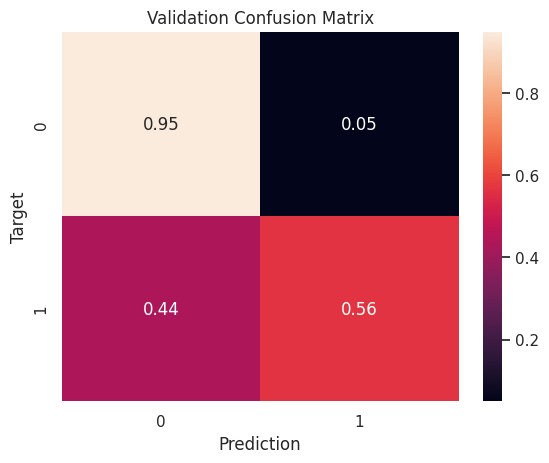

In [55]:
train_preds = predict_and_plot(X_val, y_val, 'Validation')

In [34]:
from sklearn.metrics import f1_score

print("Train F1 Score:", f1_score(y_train, train_pred))
print("Validation F1 Score:", f1_score(y_val, val_pred))


Train F1 Score: 0.6352429296591733
Validation F1 Score: 0.641192917054986


Модель непогана. Крім того Accuracy та F1 валідацйного набору є близьким до тестового, що є непоганим результатом.

In [35]:
from sklearn.metrics import roc_auc_score

print("Train AUROC:", roc_auc_score(y_train, train_proba))
print("Validation AUROC:", roc_auc_score(y_val, val_proba))


Train AUROC: 0.8823886375675453
Validation AUROC: 0.8796714452294396


Показник відділення класів моделі AUROC доволі високий 0,88.

In [60]:
from sklearn.metrics import roc_curve, auc

def compute_auroc_and_build_roc(inputs, targets, name=''):
  # Predict probabilities
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

    # Compute AUROC
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.2f}')

  # Plot the ROC curve
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

AUROC for Training: 0.88


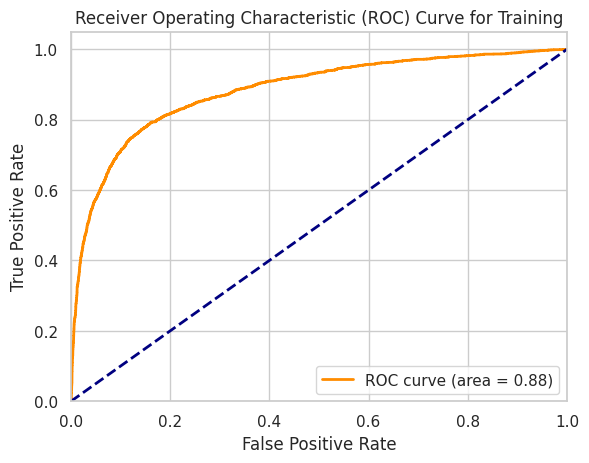

AUROC for Validation: 0.88


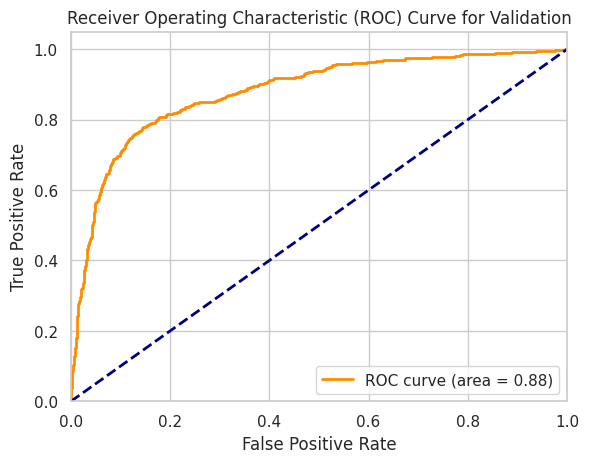

In [61]:
compute_auroc_and_build_roc(X_train, y_train, 'Training')
compute_auroc_and_build_roc(X_val, y_val, 'Validation')

Крива:значно вище діагоналі, близька до верхнього лівого кута, модель робить мало помилкових позитивів, модель робить багато правильних позитивів

Модель LogisticRegression показує високий показник AUROC 0.88, що свідчить про хорошу здатність відділяти клієнтів, які йдуть, від тих, хто залишаються.
Водночас F1 Score на тренувальному (0.63) та валідаційному (0.64) наборах є відносно низьким, що вказує на значну кількість помилкових негативів.
Confusion matrix демонструє, що модель часто не виявляє клієнтів, які ймовірно підуть (FN = 1128 на train та 266 на val).
Загалом модель має задовільну якість.

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [37]:
majority_class = y_train.mode()[0]
print("Мажоритарний клас:", majority_class)


Мажоритарний клас: 0.0


In [38]:
train_majority_pred = np.full_like(y_train, fill_value=majority_class)
val_majority_pred = np.full_like(y_val, fill_value=majority_class)


In [39]:
from sklearn.metrics import accuracy_score

train_majority_acc = accuracy_score(y_train, train_majority_pred)
val_majority_acc = accuracy_score(y_val, val_majority_pred)

print("Train Accuracy (majority model):", train_majority_acc)
print("Validation Accuracy (majority model):", val_majority_acc)


Train Accuracy (majority model): 0.7965
Validation Accuracy (majority model): 0.7966666666666666


In [40]:
train_lr_acc = accuracy_score(y_train, train_pred)
val_lr_acc = accuracy_score(y_val, val_pred)

print("Train Accuracy (LogisticRegression):", train_lr_acc)
print("Validation Accuracy (LogisticRegression):", val_lr_acc)


Train Accuracy (LogisticRegression): 0.87425
Validation Accuracy (LogisticRegression): 0.8716666666666667


Мажоритарний клас у тренувальних даних - 0, тобто більшість клієнтів не йдуть.
Мажоритарна модель дає Accuracy приблизно 0.80, тоді як LogisticRegression показує значно вищу точність приблизно 0.87.
Крім того, LogisticRegression має високий AUROC 0.88, що свідчить про хороше розділення класів.
Отже, наша модель є задовільною і суттєво кращою за базову.

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [41]:
import joblib

In [42]:
joblib.dump(model, 'log_reg.joblib')

['log_reg.joblib']

In [43]:
model_2 = joblib.load('log_reg.joblib')


In [44]:
print(model_2)

LogisticRegression(solver='liblinear')


10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [62]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, input_df: pd.DataFrame):
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    X_input = input_df[numeric_cols + encoded_cols]
    prob = model.predict_proba(X_input)[:,1]
    return prob

In [64]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(model, scaler, encoder, numeric_cols, categorical_cols, input_df: pd.DataFrame):
    df = input_df.copy()

    # Масштабування числових колонок
    df[numeric_cols] = scaler.transform(df[numeric_cols])

    # Кодування категоріальних колонок
    encoded = encoder.transform(df[categorical_cols])
    encoded_cols = encoder.get_feature_names_out(categorical_cols)

    # Додаємо закодовані колонки
    df[encoded_cols] = encoded

    # Формуємо X_input у правильному порядку
    X_input = df[numeric_cols + list(encoded_cols)]

    # Передбачення
    prob = model.predict_proba(X_input)[:, 1]
    return prob



11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [77]:
raw_df = pd.read_csv('/content/sample_data/test.csv')


In [78]:
raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


In [79]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# 1. Визначаємо колонки

numeric_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance',
    'NumOfProducts', 'HasCrCard', 'IsActiveMember',
    'EstimatedSalary'
]

categorical_cols = ['Geography', 'Gender']


# 2. Створюємо препроцесинг (масштабування + one-hot encoding)

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)


# 3. Створюємо Pipeline з моделлю

pipe = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression())
])

# 4. Навчання Pipeline

# train_df має містити всі колонки numeric + categorical + таргет Exited
X_train = train_df[numeric_cols + categorical_cols]
y_train = train_df['Exited']

pipe.fit(X_train, y_train)

# 5. Зчитуємо test.csv

test_raw_df = pd.read_csv('/content/sample_data/test.csv')

# 6. Передбачення для кожного рядка test_raw_df

test_raw_df['Exited'] = pipe.predict_proba(test_raw_df[numeric_cols + categorical_cols])[:, 1]

# 7. Виводимо результат
test_raw_df.head()


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.069305
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.033363
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.153864
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.198330
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.054045


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [84]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# 1. Визначаємо колонки
numeric_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance',
    'NumOfProducts', 'HasCrCard', 'IsActiveMember',
    'EstimatedSalary'
]

categorical_cols = ['Geography', 'Gender']

# 2. Створюємо препроцесинг
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# 3. Створюємо Pipeline
pipe = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression())
])

# 4. Навчання Pipeline
X_train = train_df[numeric_cols + categorical_cols]
y_train = train_df['Exited']
pipe.fit(X_train, y_train)

# 5. Зчитуємо sample_submission.csv
sub_df = pd.read_csv('/content/sample_data/sample_submission.csv')

# 6. Зчитуємо test.csv
test_raw_df = pd.read_csv('/content/sample_data/test.csv')

# 7. Передбачення через Pipeline
preds = pipe.predict_proba(test_raw_df[numeric_cols + categorical_cols])[:, 1]

# 8. Заповнюємо колонку Exited
sub_df['Exited'] = preds

# 9. Виводимо перші 5 рядків
print(sub_df.head())

# 10. Зберігаємо файл без індексів
sub_df.to_csv('submission_log_reg.csv', index=False)


      id    Exited
0  15000  0.069305
1  15001  0.033363
2  15002  0.153864
3  15003  0.198330
4  15004  0.054045
